<a href="https://colab.research.google.com/github/rudra-raghuwanshi/CODSOFT/blob/main/Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub

import os
import kagglehub

path = kagglehub.dataset_download("hijest/genre-classification-dataset-imdb")
print("Path to dataset files:", path)

def find_file(root, filename):
    for dirpath, _, files in os.walk(root):
        if filename in files:
            return os.path.join(dirpath, filename)
    raise FileNotFoundError(f"Could not find {filename} under {root}")

TRAIN_FILE = find_file(path, "train_data.txt")
TEST_SOLUTION_FILE = find_file(path, "test_data_solution.txt")
print("Train file:", TRAIN_FILE)
print("Test file (with true labels):", TEST_SOLUTION_FILE)

100%|██████████| 41.7M/41.7M [00:00<00:00, 86.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hijest/genre-classification-dataset-imdb/versions/1
Train file: /root/.cache/kagglehub/datasets/hijest/genre-classification-dataset-imdb/versions/1/Genre Classification Dataset/train_data.txt
Test file (with true labels): /root/.cache/kagglehub/datasets/hijest/genre-classification-dataset-imdb/versions/1/Genre Classification Dataset/test_data_solution.txt


In [2]:
import pandas as pd

def load_labeled(file_path):
    df = pd.read_csv(file_path, sep=" ::: ", engine="python", header=None,
                      names=["ID", "TITLE", "GENRE", "DESCRIPTION"])
    df["GENRE"] = df["GENRE"].str.strip()
    return df

train_df = load_labeled(TRAIN_FILE)
test_df = load_labeled(TEST_SOLUTION_FILE)

print(f"Train rows: {len(train_df):,}   Genres: {train_df['GENRE'].nunique()}")
print(f"Test rows: {len(test_df):,}")
train_df.head()

Train rows: 54,214   Genres: 27
Test rows: 54,200


,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


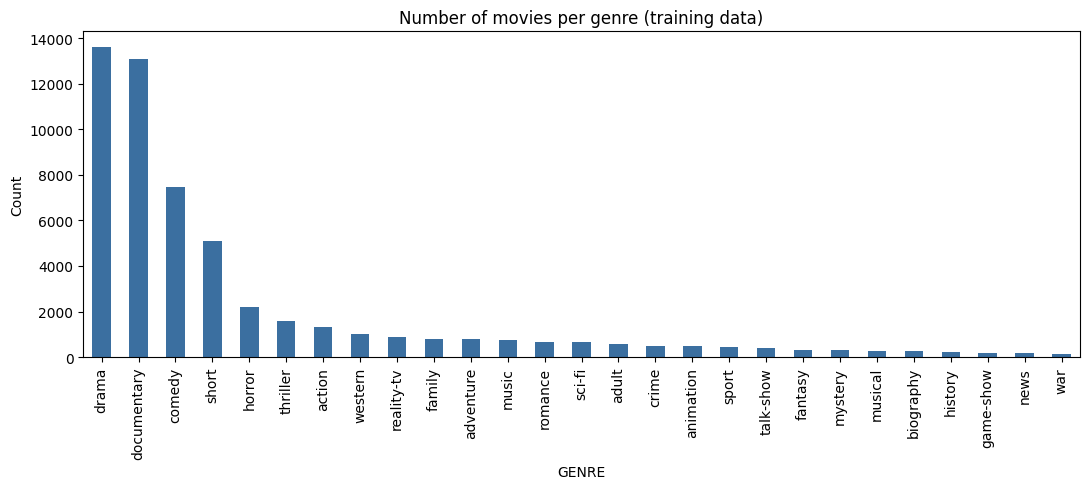

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))
train_df["GENRE"].value_counts().plot(kind="bar", color="#3b6fa0")
plt.title("Number of movies per genre (training data)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["DESCRIPTION"].apply(clean_text)
test_df["clean_text"] = test_df["DESCRIPTION"].apply(clean_text)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_val, y_train, y_val = train_test_split(
    train_df["clean_text"], train_df["GENRE"],
    test_size=0.10, random_state=42, stratify=train_df["GENRE"]
)

TFIDF_PARAMS = dict(max_features=50000, ngram_range=(1, 2),
                     sublinear_tf=True, stop_words="english", min_df=2)
vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 50000


In [6]:
import time
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

candidates = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=300, class_weight="balanced"),
    "Linear SVM": LinearSVC(C=1.0, class_weight="balanced", max_iter=3000),
}

best_name, best_f1 = None, -1
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train_vec, y_train)
    pred = model.predict(X_val_vec)
    acc = accuracy_score(y_val, pred)
    f1_w = f1_score(y_val, pred, average="weighted")
    f1_m = f1_score(y_val, pred, average="macro")
    print(f"{name:<26} acc={acc:.4f}  f1_weighted={f1_w:.4f}  f1_macro={f1_m:.4f}  ({time.time()-t0:.1f}s)")
    if f1_w > best_f1:
        best_f1, best_name = f1_w, name

print(f"\nBest model: {best_name}")

Multinomial Naive Bayes    acc=0.5546  f1_weighted=0.4932  f1_macro=0.2252  (0.6s)
Logistic Regression        acc=0.5061  f1_weighted=0.5239  f1_macro=0.3739  (48.0s)
Linear SVM                 acc=0.5638  f1_weighted=0.5634  f1_macro=0.3782  (15.0s)

Best model: Linear SVM


In [7]:
import joblib
from sklearn.base import clone

full_vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_full_vec = full_vectorizer.fit_transform(train_df["clean_text"])

final_model = clone(candidates[best_name])
final_model.fit(X_full_vec, train_df["GENRE"])

joblib.dump(final_model, "genre_classifier.pkl")
joblib.dump(full_vectorizer, "tfidf_vectorizer.pkl")
print("Saved model + vectorizer.")

Saved model + vectorizer.


FINAL TEST SET RESULTS
Accuracy:      0.5662
F1 (weighted): 0.5682
F1 (macro):    0.3838

              precision    recall  f1-score   support

      action       0.34      0.47      0.40      1314
       adult       0.47      0.61      0.53       590
   adventure       0.28      0.30      0.29       775
   animation       0.26      0.26      0.26       498
   biography       0.05      0.03      0.04       264
      comedy       0.59      0.56      0.58      7446
       crime       0.17      0.21      0.19       505
 documentary       0.76      0.77      0.76     13096
       drama       0.67      0.57      0.61     13612
      family       0.22      0.26      0.24       783
     fantasy       0.15      0.16      0.15       322
   game-show       0.67      0.73      0.70       193
     history       0.09      0.06      0.07       243
      horror       0.54      0.70      0.61      2204
       music       0.49      0.68      0.57       731
     musical       0.20      0.19      0.20  

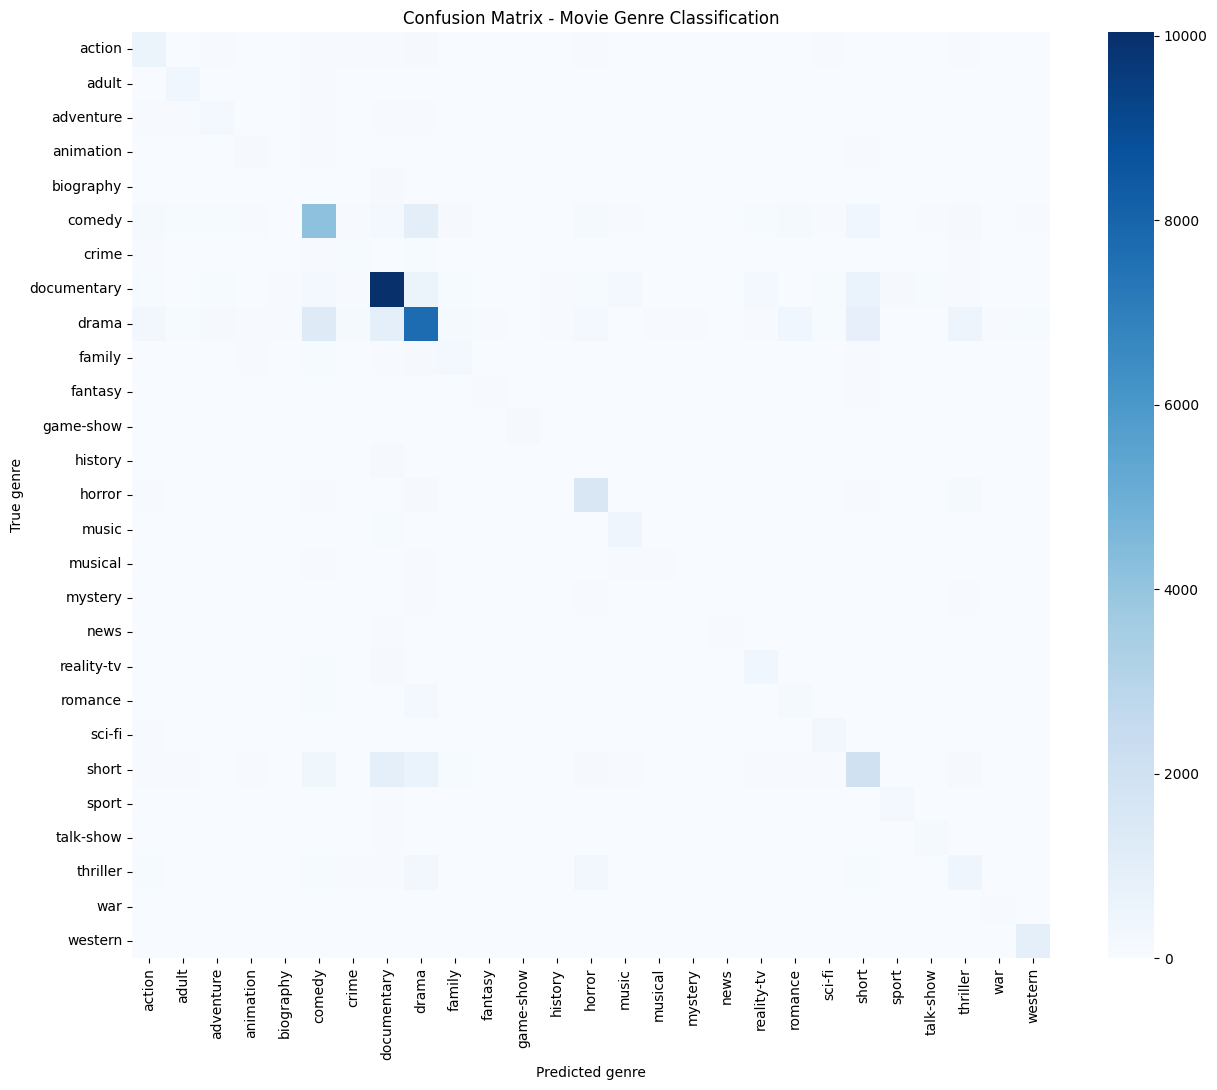

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

X_test_vec = full_vectorizer.transform(test_df["clean_text"])
y_pred = final_model.predict(X_test_vec)

acc = accuracy_score(test_df["GENRE"], y_pred)
f1_w = f1_score(test_df["GENRE"], y_pred, average="weighted")
f1_m = f1_score(test_df["GENRE"], y_pred, average="macro")

print("FINAL TEST SET RESULTS")
print(f"Accuracy:      {acc:.4f}")
print(f"F1 (weighted): {f1_w:.4f}")
print(f"F1 (macro):    {f1_m:.4f}\n")
print(classification_report(test_df["GENRE"], y_pred, zero_division=0))

labels = sorted(test_df["GENRE"].unique())
cm = confusion_matrix(test_df["GENRE"], y_pred, labels=labels)
plt.figure(figsize=(13, 11))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted genre"); plt.ylabel("True genre")
plt.title("Confusion Matrix - Movie Genre Classification")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

def predict_genre(description, top_k=3):
    cleaned = clean_text(description)
    vec = full_vectorizer.transform([cleaned])
    pred = final_model.predict(vec)[0]
    scores = final_model.decision_function(vec)[0]
    top_idx = np.argsort(scores)[::-1][:top_k]
    print(f"Predicted genre: {pred.upper()}")
    print("Top candidates:")
    for i in top_idx:
        print(f"  {final_model.classes_[i]:<15} score={scores[i]:.3f}")

predict_genre("A group of astronauts get stranded on a distant planet and must find a way back to Earth before their oxygen runs out.")

Predicted genre: SCI-FI
Top candidates:
  sci-fi          score=-0.002
  adventure       score=-0.572
  short           score=-0.675


In [11]:
while True:
    text = input("Plot description (or 'exit'): ").strip()
    if text.lower() == "exit":
        break
    predict_genre(text)

Plot description (or 'exit'): A robot gains self-awareness aboard a spaceship and must decide whether to help or betray its human crew.
Predicted genre: SCI-FI
Top candidates:
  sci-fi          score=-0.471
  short           score=-0.479
  animation       score=-0.577
Plot description (or 'exit'): A detective investigates a string of murders in a small coastal town, uncovering a decades-old conspiracy.
Predicted genre: THRILLER
Top candidates:
  thriller        score=-0.218
  mystery         score=-0.585
  crime           score=-0.738
Plot description (or 'exit'): exit
